# Transfer Learning


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

import PIL.Image as Image
import cv2

import tensorflow as tf

import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [11]:
import tensorflow as tf
import tf_keras as keras
import tensorflow_hub as hub

In [14]:
keras.__version__, tf.__version__, tf.keras.__version__, hub.__version__

('2.21.0', '2.21.0', '3.15.0', '0.16.1')

In [15]:
IMAGE_SHAPE = (224, 224)

classifier = keras.Sequential(
    [
        hub.KerasLayer(
            "https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/classification/5",
            input_shape=IMAGE_SHAPE + (3,),
        )
    ]
)

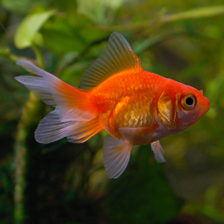

In [17]:
goldfish = Image.open("./goldfish.jpg").resize(IMAGE_SHAPE)
goldfish

In [18]:
goldfish = np.array(goldfish) / 255.0
goldfish.shape

(224, 224, 3)

In [19]:
goldfish[np.newaxis, ...].shape

(1, 224, 224, 3)

In [21]:
result = classifier.predict(goldfish[np.newaxis, ...])
result.shape

1/1 [==============================] - 0s 87ms/step


(1, 1001)

In [23]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(2)

In [25]:
image_labels = []
with open("ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [26]:
image_labels[predicted_label_index]

'goldfish'

In [28]:
image_labels.__len__()

1001

In [42]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    "flower_photos", origin=dataset_url, cache_dir="./", untar=True
)

In [45]:
import pathlib

data_dir = pathlib.Path(data_dir)

list(data_dir.glob("**/*.jpg"))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [46]:
image_count = len(list(data_dir.glob("**/*.jpg")))
print("Total number of images:", image_count)

Total number of images: 3670


In [51]:
roses = list(data_dir.glob("flower_photos/roses/*"))
tulips = list(data_dir.glob("flower_photos/tulips/*"))
sunflowers = list(data_dir.glob("flower_photos/sunflowers/*"))
dandelions = list(data_dir.glob("flower_photos/dandelion/*"))
daisy = list(data_dir.glob("flower_photos/daisy/*"))
print(len(roses), len(tulips), len(sunflowers), len(dandelions), len(daisy))

641 799 699 898 633


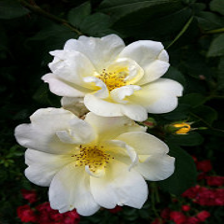

In [48]:
Image.open(roses[0]).resize(IMAGE_SHAPE)

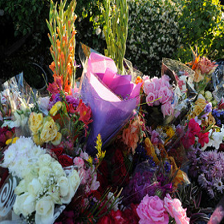

In [50]:
Image.open(roses[3]).resize(IMAGE_SHAPE)

In [52]:
flowers_images_dict = {
    "roses": list(data_dir.glob("flower_photos/roses/*")),
    "daisy": list(data_dir.glob("flower_photos/daisy/*")),
    "dandelion": list(data_dir.glob("flower_photos/dandelion/*")),
    "sunflowers": list(data_dir.glob("flower_photos/sunflowers/*")),
    "tulips": list(data_dir.glob("flower_photos/tulips/*")),
}

In [53]:
flowers_labels_dict = {
    "roses": 0,
    "daisy": 1,
    "dandelion": 2,
    "sunflowers": 3,
    "tulips": 4,
}

In [55]:
str(flowers_images_dict["roses"][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [56]:
img = cv2.imread(str(flowers_images_dict["roses"][0]))
img.shape

(240, 179, 3)

In [57]:
x, y = [], []
for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        img = cv2.resize(img, IMAGE_SHAPE)
        x.append(img)
        y.append(flowers_labels_dict[flower_name])

In [58]:
x = np.array(x)
y = np.array(y)

In [59]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [60]:
x_train_scaled = x_train / 255.0
x_test_scaled = x_test / 255.0

In [63]:
predicted = classifier.predict(np.array([x[0], x[1], x[2]]))

1/1 [==============================] - 0s 93ms/step


In [64]:
predicted = np.argmax(predicted, axis=1)

In [65]:
predicted

array([795, 880, 795])

In [69]:
image_labels[795]

'shower curtain'

In [71]:
feature_extractor_model = (
    "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
)
pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=IMAGE_SHAPE + (3,), trainable=False
)

In [74]:
num_of_flowers = len(flowers_labels_dict)

model = keras.Sequential(
    [
        pretrained_model_without_top_layer,
        keras.layers.Dense(num_of_flowers),
    ]
)
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_7 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [77]:
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["acc"],
)
model.fit(x_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 [==============================] - 25s 256ms/step - loss: 0.3864 - acc: 0.8677
Epoch 2/5
86/86 [==============================] - 21s 247ms/step - loss: 0.2869 - acc: 0.9088
Epoch 3/5
86/86 [==============================] - 21s 248ms/step - loss: 0.2398 - acc: 0.9266
Epoch 4/5
86/86 [==============================] - 21s 246ms/step - loss: 0.2100 - acc: 0.9386
Epoch 5/5
86/86 [==============================] - 22s 252ms/step - loss: 0.1820 - acc: 0.9499


In [78]:
model.evaluate(x_test_scaled, y_test)

29/29 [==============================] - 10s 292ms/step - loss: 0.3687 - acc: 0.8715


[0.36872026324272156, 0.8714597225189209]